In [1]:

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv("it_jobs.csv")
print("Kích thước dữ liệu:", df.shape)
print("Các cột trong dữ liệu:")
print(df.columns)

df.head()

Kích thước dữ liệu: (2041, 14)
Các cột trong dữ liệu:
Index(['company_id', 'company_name', 'average_rating', 'num_review', 'city',
       'type', 'num_employee', 'country', 'working_day', 'OT', 'overview',
       'expertise', 'benifit', 'logo_link'],
      dtype='str')


,company_id,company_name,average_rating,num_review,city,type,num_employee,country,working_day,OT,overview,expertise,benifit,logo_link
0,kms-technology,KMS Technology,4.0,197 Reviews,"Ho Chi Minh, Da Nang, Ha Noi",Outsourcing,1000+,United States,Monday - Friday,No OT,"Established in 2009, KMS Technology is a U.S.-...",NaN,Want to be the Best? Join KMS!\n\n\nIt’s posit...,https://itviec.com/rails/active_storage/repres...
1,nab-in-collaboration-with-positive-thinking-co...,NAB in collaboration with Positive Thinking Co...,4.4,11 Reviews,Ho Chi Minh,Product,501-1000,Australia,Monday - Friday,No OT,NAB in collaboration with Positive Thinking Co...,Languages &amp; Frameworks\n\n\nJavaScript ES6...,THE BENEFITS AND PERKS\n\n\n\n\nVery competiti...,https://itviec.com/rails/active_storage/repres...
2,robert-bosch-engineering-and-business-solutions,Robert Bosch Engineering And Business Solutions,3.2,217 Reviews,"Ho Chi Minh, Ha Noi",Product,1-50,Germany,Monday - Friday,No OT,Robert BOSCH Engineering and Business Solution...,Embedded Software for Automotive Applications\...,Why \nBOSCH\n?\n\nBecause we don't just follow...,https://itviec.com/rails/active_storage/repres...
3,gft-technologies-vietnam,GFT Technologies Vietnam,NaN,Reviews,"Ho Chi Minh, Ha Noi",Outsourcing,51-150,Germany,Monday - Friday,No OT,Working at GFT Vietnam\n\n\nGFT is driving the...,"Technical frameworks\n\n\nJava/Kotlin, Spring ...",HR benefits\n\n\n\n\nCompetitive salary\n\n\nS...,https://itviec.com/rails/active_storage/repres...
4,tyme,Tyme,4.6,29 Reviews,"Ho Chi Minh, Ha Noi",Product,151-300,Vietnam,Monday - Friday,No OT,Tyme Vietnam\n is the international arm of \nT...,Mobile/ Tablet Development: \nNative Android/i...,Our goal is simple: to be the #1 digital techn...,https://itviec.com/rails/active_storage/repres...


In [5]:
df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna("")

print("Số dòng sau khi làm sạch:", len(df))

Số dòng sau khi làm sạch: 2041


In [ ]:
Câu 1. Thành phố nào có nhu cầu tuyển dụng CNTT cao nhất tại Việt Nam?

CÂU 1: THÀNH PHỐ CÓ NHU CẦU TUYỂN DỤNG CNTT CAO NHẤT

Top 10 thành phố có nhiều tin tuyển dụng nhất:
Thanh_pho
Ho Chi Minh    1368
Ha Noi          885
District 1      190
Cau Giay        171
Tan Binh        157
Da Nang         136
Binh Thanh      112
Nam Tu Liem     107
District 3      104
Others           93
Name: count, dtype: int64

Thành phố có nhu cầu tuyển dụng cao nhất: Ho Chi Minh
Số lượng tin tuyển dụng: 1368


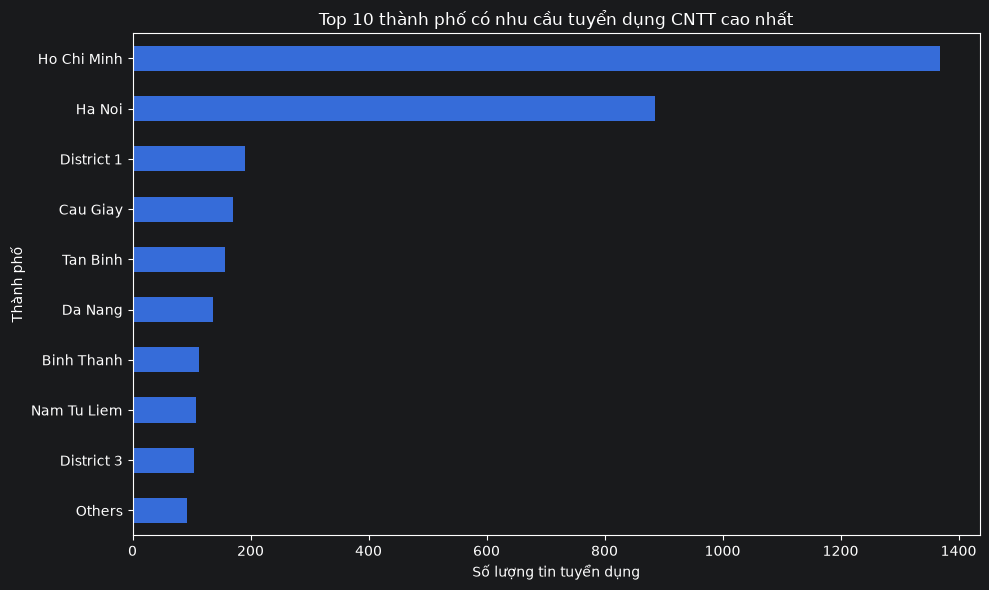

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
city_list = []
#
for cities in df["city"]:
    #
    parts = str(cities).split(",")
    for city in parts:
        city = city.strip()
        if city != "":
            city_list.append(city)
city_df = pd.DataFrame(
    city_list,
    columns=["Thanh_pho"]
)
#
city_count = (
    city_df["Thanh_pho"]
    .value_counts()
)
print("=" * 70)
print("CÂU 1: THÀNH PHỐ CÓ NHU CẦU TUYỂN DỤNG CNTT CAO NHẤT")
print("=" * 70)
print("\nTop 10 thành phố có nhiều tin tuyển dụng nhất:")
print(city_count.head(10))
print(
    "\nThành phố có nhu cầu tuyển dụng cao nhất:",
    city_count.index[0]
)
print(
    "Số lượng tin tuyển dụng:",
    city_count.iloc[0]
)
top10_city = city_count.head(10)
plt.figure(figsize=(10, 6))
#
top10_city.sort_values().plot(
    kind="barh"
)
plt.title(
    "Top 10 thành phố có nhu cầu tuyển dụng CNTT cao nhất"
)
plt.xlabel("Số lượng tin tuyển dụng")
plt.ylabel("Thành phố")
plt.tight_layout()
plt.show()

In [ ]:
Câu 2. Những vị trí CNTT nào đang được tuyển dụng nhiều nhất?

Các vị trí CNTT được tuyển dụng nhiều nhất:
Danh_sach_vi_tri
Khác / Không xác định    1577
Data / AI Engineer        412
Business Analyst          359
Backend Developer         295
Frontend Developer        236
Mobile Developer          209
DevOps Engineer           187
Embedded Developer         53
Tester / QA / QC           35
Security Engineer          29
Fullstack Developer        16
Project Manager            11
Name: count, dtype: int64


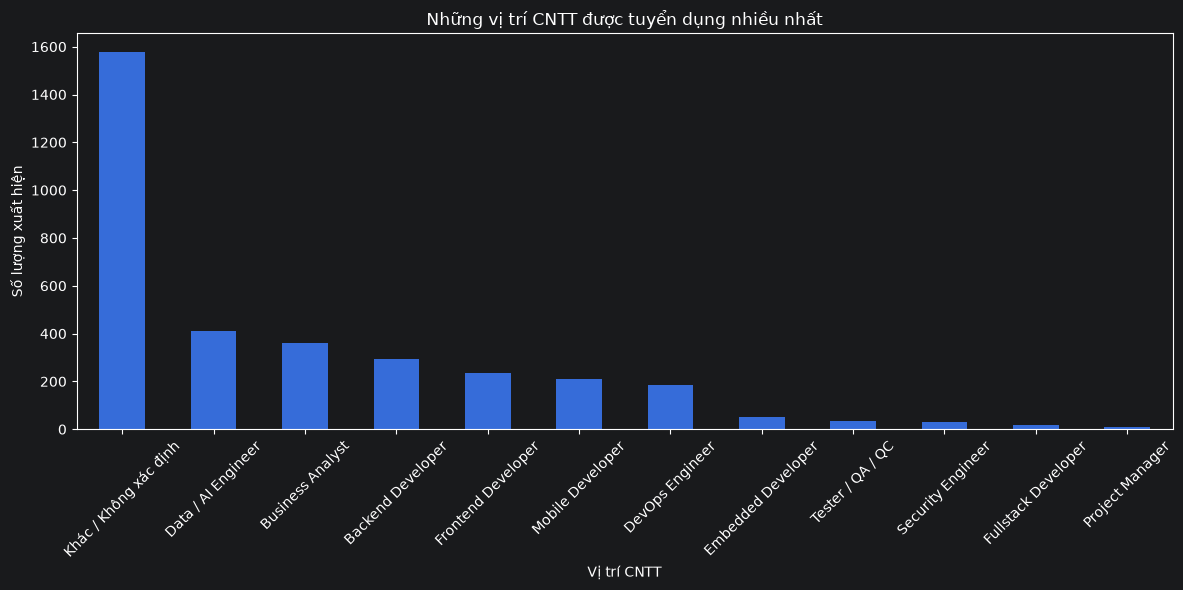

Vị trí CNTT phổ biến nhất là: Khác / Không xác định


In [8]:
#
def detect_job_position(text):
    text = str(text).lower()

    job_keywords = {
       "Backend Developer": [
            "backend", "back-end", "java", "spring", ".net", "node.js",
            "php", "golang", "api", "server"
        ],
        "Frontend Developer": [
            "frontend", "front-end", "react", "angular", "vue",
            "javascript", "typescript", "html", "css"
        ],
        "Fullstack Developer": [
            "fullstack", "full-stack", "full stack"
        ],
        "Mobile Developer": [
            "mobile", "android", "ios", "swift", "kotlin", "flutter",
            "react native"
        ],
        "Data / AI Engineer": [
            "data", "ai", "machine learning", "deep learning",
            "python", "data engineer", "data scientist"
        ],
        "DevOps Engineer": [
            "devops", "docker", "kubernetes", "aws", "azure",
            "cloud", "ci/cd", "jenkins"
        ],
        "Tester / QA / QC": [
            "tester", "qa", "qc", "quality assurance", "automation test",
            "manual test", "selenium"
        ],
        "Embedded Developer": [
            "embedded", "iot", "firmware", "c/c++", "automotive"
        ],
        "Business Analyst": [
            "business analyst", "ba", "analyst"
        ],
        "Project Manager": [
            "project manager", "scrum master", "product owner",
            "product manager"
        ],
        "Security Engineer": [
            "security", "cybersecurity", "information security",
            "pentest", "devsecops"
        ]
    }
    detected = []
    for position, keywords in job_keywords.items():
        for kw in keywords:
            if kw in text:
                detected.append(position)
                break
    if len(detected) == 0:
        return ["Khác / Không xác định"]
    return detected
#
df["text_for_position"] = (
    df["expertise"].astype(str) + " " +
    df["overview"].astype(str) + " " +
    df["benifit"].astype(str)
)


df["Danh_sach_vi_tri"] = df["text_for_position"].apply(detect_job_position)
position_exploded = df.explode("Danh_sach_vi_tri")
#
position_count = position_exploded["Danh_sach_vi_tri"].value_counts()

print("Các vị trí CNTT được tuyển dụng nhiều nhất:")
print(position_count)
plt.figure(figsize=(12, 6))
position_count.plot(kind="bar")
plt.title("Những vị trí CNTT được tuyển dụng nhiều nhất")
plt.xlabel("Vị trí CNTT")
plt.ylabel("Số lượng xuất hiện")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("Vị trí CNTT phổ biến nhất là:", position_count.index[0])

In [ ]:
câu 3 Những kỹ năng CNTT nào được yêu cầu nhiều nhất?

CÂU 3: NHỮNG KỸ NĂNG CNTT ĐƯỢC YÊU CẦU NHIỀU NHẤT

Top 20 kỹ năng phổ biến nhất:
Danh_sach_ky_nang
Python          44
Java            43
ReactJS         38
MySQL           38
PHP             36
MongoDB         31
Docker          29
NodeJS          29
CSS             26
Redis           25
Android         25
AWS             24
JavaScript      23
Kubernetes      22
React Native    21
...             20
VueJS           19
HTML5           19
HTML            18
Swift           17
Name: count, dtype: int64

KẾT LUẬN:
Kỹ năng được yêu cầu nhiều nhất là: Python
Số lần xuất hiện: 44


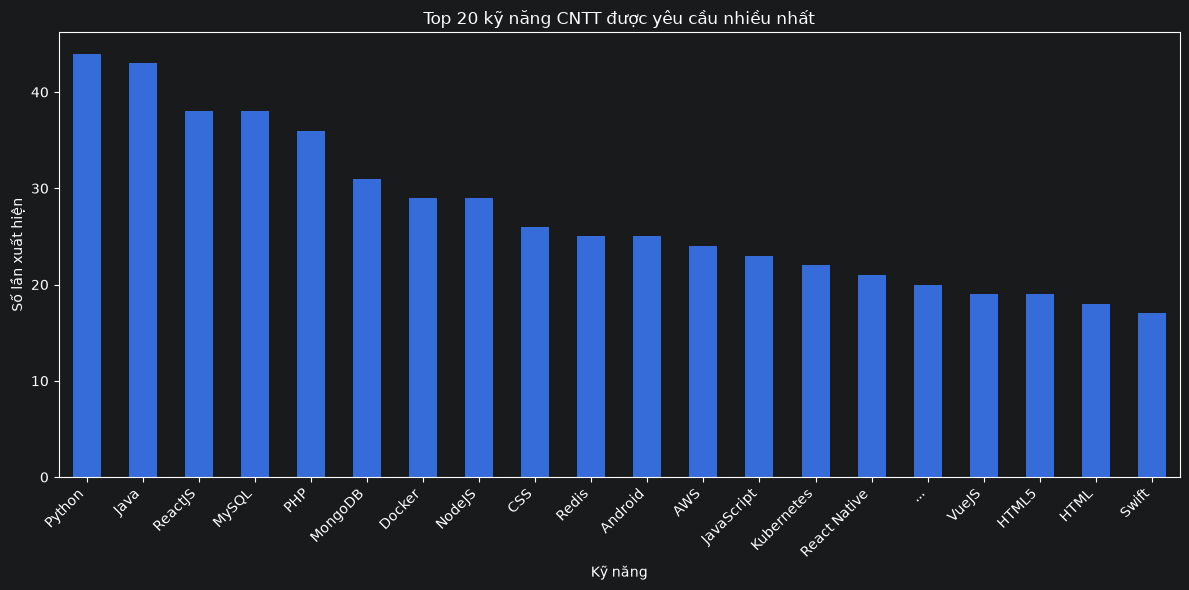

In [23]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
#
def tach_ky_nang(text):

    if pd.isna(text):
        return []
    text = str(text)
    for char in ["\n", ";", "/", "|"]:
        text = text.replace(char, ",")

    skills = []

    for item in text.split(","):
        item = item.strip()

        if item != "" and len(item) >= 2:
            skills.append(item)

    return skills


df["Danh_sach_ky_nang"] = df["expertise"].apply(tach_ky_nang)

#
skill_exploded = df.explode("Danh_sach_ky_nang")
#
skill_count = (
    skill_exploded["Danh_sach_ky_nang"]
    .value_counts()
)

print("=" * 70)
print("CÂU 3: NHỮNG KỸ NĂNG CNTT ĐƯỢC YÊU CẦU NHIỀU NHẤT")
print("=" * 70)

print("\nTop 20 kỹ năng phổ biến nhất:")
print(skill_count.head(20))

top_skill = skill_count.index[0]
top_skill_count = skill_count.iloc[0]

print("\nKẾT LUẬN:")
print(f"Kỹ năng được yêu cầu nhiều nhất là: {top_skill}")
print(f"Số lần xuất hiện: {top_skill_count}")

plt.figure(figsize=(12, 6))
skill_count.head(20).plot(kind="bar")

plt.title("Top 20 kỹ năng CNTT được yêu cầu nhiều nhất")
plt.xlabel("Kỹ năng")
plt.ylabel("Số lần xuất hiện")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
Câu 4. Những kỹ năng nào thường xuất hiện cùng nhau?

Top kỹ năng xuất hiện nhiều nhất:
nan             1564
Java              40
Python            40
MySQL             38
PHP               33
ReactJS           33
MongoDB           31
NodeJS            29
Docker            26
Redis             25
AWS               23
JavaScript        22
Android           22
React Native      20
Kubernetes        19
VueJS             18
CSS               17
PostgreSQL        16
Angular           15
...               15
Javascript        15
Swift             14
C#                13
Jenkins           13
iOS               13
HTML5             13
.NET              13
HTML              13
AngularJS         13
Golang            13
dtype: int64


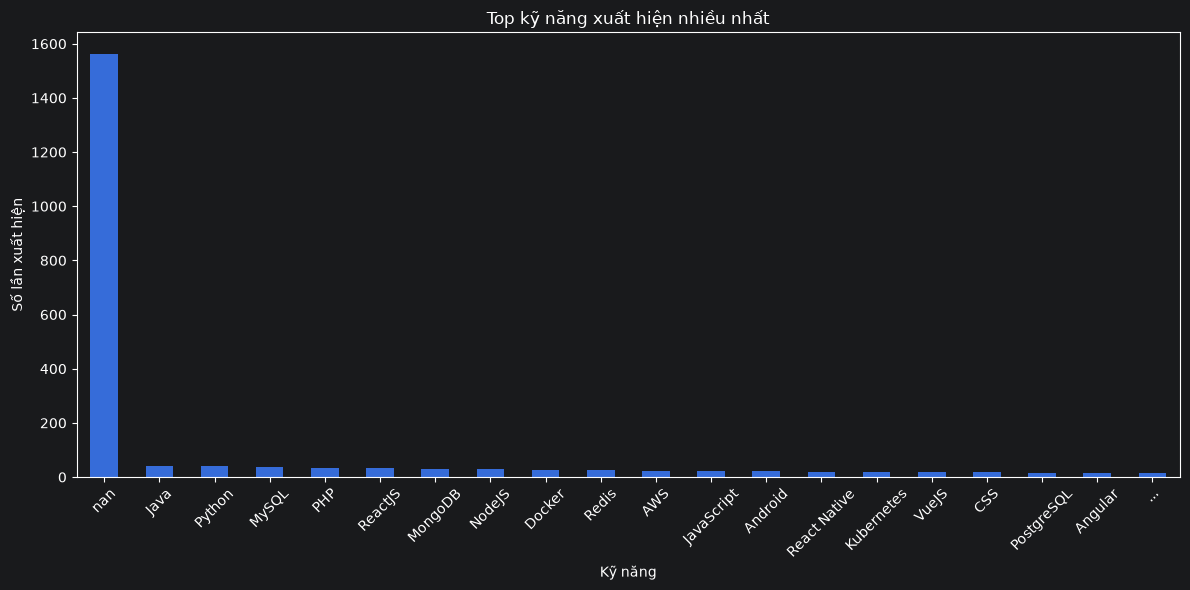

Các kỹ năng thường xuất hiện cùng nhau:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [11]:
def clean_skill(skill):
    skill = str(skill).strip()
    skill = skill.replace("&amp;", "&")
    skill = re.sub(r'\s+', ' ', skill)
    return skill
def split_skills(text):

    text = str(text)
    raw_skills = re.split(r'[,;\n]', text)
    skills = []
    for skill in raw_skills:
        skill = clean_skill(skill)
        if len(skill) >= 2 and len(skill) <= 40:
            skills.append(skill)
    return list(set(skills))

df["Danh_sach_ky_nang"] = df["expertise"].apply(split_skills)
#
mlb = MultiLabelBinarizer()
#
skill_encoded = mlb.fit_transform(df["Danh_sach_ky_nang"])

skill_matrix = pd.DataFrame(
    skill_encoded,
    columns=mlb.classes_
)
skill_sum = skill_matrix.sum().sort_values(ascending=False)
top_skill_names = skill_sum[skill_sum >= 10].index

skill_matrix_filtered = skill_matrix[top_skill_names]

print("Top kỹ năng xuất hiện nhiều nhất:")
print(skill_sum.head(30))

plt.figure(figsize=(12, 6))
skill_sum.head(20).plot(kind="bar")
plt.title("Top kỹ năng xuất hiện nhiều nhất")
plt.xlabel("Kỹ năng")
plt.ylabel("Số lần xuất hiện")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#
frequent_itemsets = apriori(
    skill_matrix_filtered.astype(bool),
    min_support=0.02,
    use_colnames=True
)
#
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.3
)
rules = rules.sort_values(
    by=["lift", "confidence"],
    ascending=False
)
print("Các kỹ năng thường xuất hiện cùng nhau:")
print(
    rules[
        [
            "antecedents",
            "consequents",
            "support",
            "confidence",
            "lift"
        ]
    ].head(20)
)

In [ ]:
Câu 5: Mối quan hệ giữa số lượng kỹ năng yêu cầu và đánh giá công ty

CÂU 5: MỐI QUAN HỆ GIỮA SỐ LƯỢNG KỸ NĂNG VÀ ĐÁNH GIÁ CÔNG TY

Số lượng mẫu phân tích: 2041
Hệ số tương quan Pearson: 0.082

Đánh giá trung bình theo nhóm số lượng kỹ năng:
Nhom_so_luong_ky_nang
Ít kỹ năng           3.98
Trung bình           4.00
Nhiều kỹ năng        4.07
Rất nhiều kỹ năng    4.08
Name: average_rating, dtype: float64


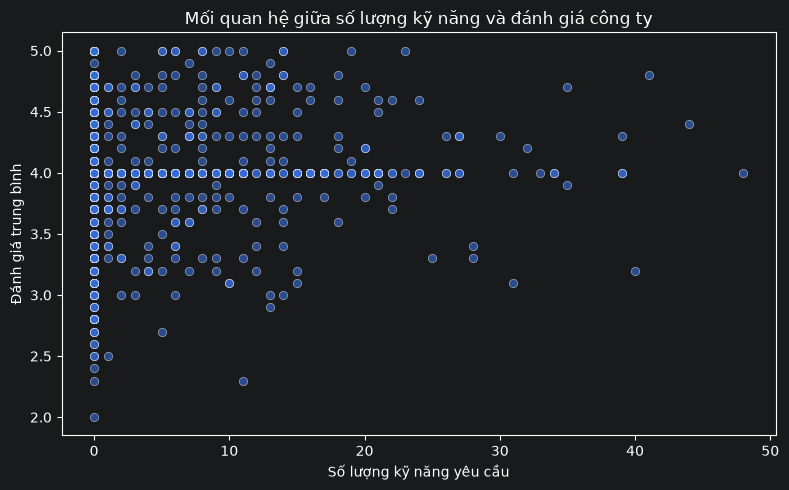

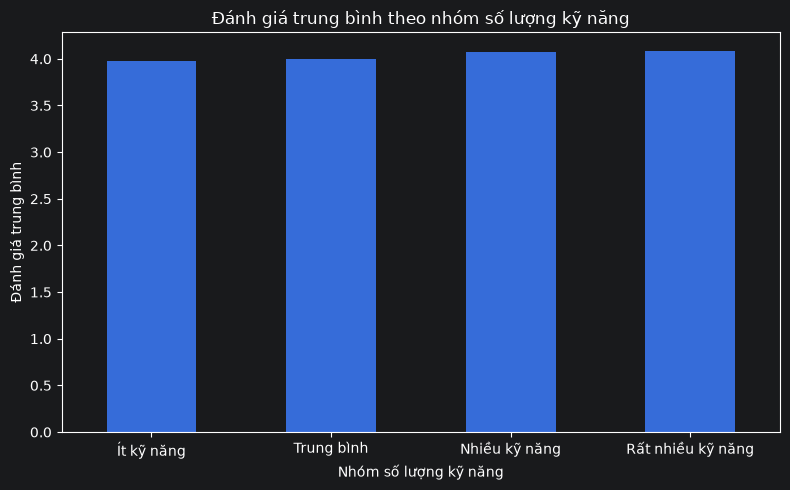

In [34]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#
df["So_luong_ky_nang"] = (
    df["Danh_sach_ky_nang"]
    .apply(len)
)
df["average_rating"] = pd.to_numeric(
    df["average_rating"],
    errors="coerce"
)
rating_skill_df = df.dropna(
    subset=[
        "So_luong_ky_nang",
        "average_rating"
    ]
)
#
corr = rating_skill_df[
    "So_luong_ky_nang"
].corr(
    rating_skill_df[
        "average_rating"
    ]
)
rating_skill_df["Nhom_so_luong_ky_nang"] = pd.cut(
    rating_skill_df["So_luong_ky_nang"],
    bins=[0, 3, 6, 10, 100],
    labels=[
        "Ít kỹ năng",
        "Trung bình",
        "Nhiều kỹ năng",
        "Rất nhiều kỹ năng"
    ],
    include_lowest=True
)
rating_by_skill_group = (
    rating_skill_df
    .groupby("Nhom_so_luong_ky_nang")
    ["average_rating"]
    .mean()
    .round(2)
)
print("=" * 70)
print("CÂU 5: MỐI QUAN HỆ GIỮA SỐ LƯỢNG KỸ NĂNG VÀ ĐÁNH GIÁ CÔNG TY")
print("=" * 70)
print(f"\nSố lượng mẫu phân tích: {len(rating_skill_df)}")
print(
    f"Hệ số tương quan Pearson: {corr:.3f}"
)
print("\nĐánh giá trung bình theo nhóm số lượng kỹ năng:")
print(rating_by_skill_group)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=rating_skill_df,
    x="So_luong_ky_nang",
    y="average_rating",
    alpha=0.6
)
plt.title(
    "Mối quan hệ giữa số lượng kỹ năng và đánh giá công ty"
)
plt.xlabel(
    "Số lượng kỹ năng yêu cầu"
)
plt.ylabel(
    "Đánh giá trung bình"
)
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 5))
rating_by_skill_group.plot(
    kind="bar"
)
plt.title(
    "Đánh giá trung bình theo nhóm số lượng kỹ năng"
)
plt.xlabel(
    "Nhóm số lượng kỹ năng"
)
plt.ylabel(
    "Đánh giá trung bình"
)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
2 câu hỏi về dự đoán, hoạc phân cụm, hoặc phân lớp sẽ trả lời là gì?

In [ ]:
1 Dự đoán vị trí tuyển dụng thuộc nhóm nghề nào dựa trên kỹ năng yêu cầu

PHÂN BỐ NHÓM NGHỀ BAN ĐẦU
Nhom_nghe
Other          1665
Frontend        230
Backend          57
AI               38
Data             20
Mobile           17
DevOps           12
Tester / QA       2
Name: count, dtype: int64

Các nhóm nghề được dùng để huấn luyện:
Nhom_nghe
Other       1665
Frontend     230
Backend       57
AI            38
Data          20
Mobile        17
DevOps        12
Name: count, dtype: int64

KẾT QUẢ DỰ ĐOÁN NHÓM NGHỀ
Độ chính xác Accuracy: 0.895

Báo cáo phân loại:
              precision    recall  f1-score   support

          AI       0.00      0.00      0.00         8
     Backend       0.80      0.33      0.47        12
        Data       0.00      0.00      0.00         4
      DevOps       0.00      0.00      0.00         2
    Frontend       0.90      0.61      0.73        46
      Mobile       0.00      0.00      0.00         3
       Other       0.90      1.00      0.94       333

    accuracy                           0.89       408
   macro avg       

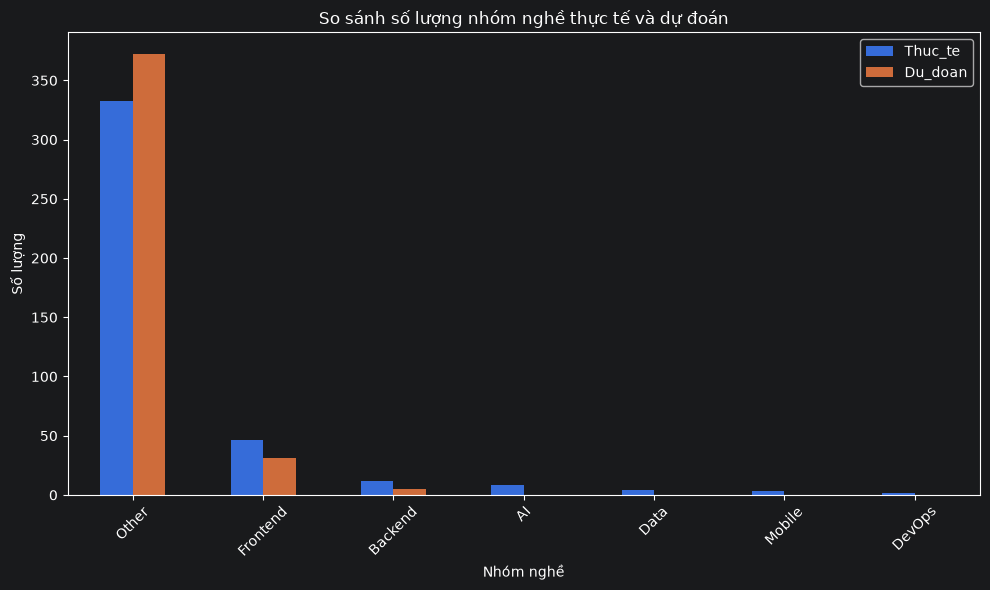

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
def tach_ky_nang(text):
    if pd.isna(text):
        return []
    text = str(text)
    for char in ["\n", ";", "/", "|"]:
        text = text.replace(char, ",")
    skills = []
    for item in text.split(","):
        item = item.strip()
        if item != "" and len(item) >= 2:
            skills.append(item)
    return skills
df["Danh_sach_ky_nang"] = df["expertise"].apply(tach_ky_nang)
#
def gan_nhom_nghe(text):
    text = str(text).lower()

    if any(x in text for x in [
        "react", "angular", "vue", "javascript", "typescript",
        "html", "css", "frontend", "front-end"
    ]):
        return "Frontend"

    elif any(x in text for x in [
        "java", "spring", ".net", "node", "nodejs", "php",
        "golang", "backend", "back-end", "api"
    ]):
        return "Backend"

    elif any(x in text for x in [
        "android", "ios", "swift", "kotlin", "flutter",
        "react native", "mobile"
    ]):
        return "Mobile"

    elif any(x in text for x in [
        "data", "sql", "etl", "big data", "database",
        "business intelligence"
    ]):
        return "Data"

    elif any(x in text for x in [
        "ai", "machine learning", "deep learning",
        "tensorflow", "pytorch", "computer vision", "nlp"
    ]):
        return "AI"

    elif any(x in text for x in [
        "devops", "docker", "kubernetes", "aws", "azure",
        "cloud", "jenkins", "ci/cd", "linux"
    ]):
        return "DevOps"

    elif any(x in text for x in [
        "tester", "qa", "qc", "selenium", "automation test",
        "manual test"
    ]):
        return "Tester / QA"

    else:
        return "Other"


df["Nhom_nghe"] = df["expertise"].apply(gan_nhom_nghe)

print("=" * 70)
print("PHÂN BỐ NHÓM NGHỀ BAN ĐẦU")
print("=" * 70)
print(df["Nhom_nghe"].value_counts())

group_count = df["Nhom_nghe"].value_counts()

valid_groups = group_count[group_count >= 10].index

df_model = df[df["Nhom_nghe"].isin(valid_groups)].copy()

print("\nCác nhóm nghề được dùng để huấn luyện:")
print(df_model["Nhom_nghe"].value_counts())
#
mlb = MultiLabelBinarizer()
#
X = pd.DataFrame(
    mlb.fit_transform(df_model["Danh_sach_ky_nang"]),
    columns=mlb.classes_
)

y = df_model["Nhom_nghe"]
#
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
#
model_career = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    class_weight="balanced"
)
#
model_career.fit(X_train, y_train)

y_pred = model_career.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\n" + "=" * 70)
print("KẾT QUẢ DỰ ĐOÁN NHÓM NGHỀ")
print("=" * 70)

print(f"Độ chính xác Accuracy: {accuracy:.3f}")

print("\nBáo cáo phân loại:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

compare_df = pd.DataFrame({
    "Thuc_te": y_test.values,
    "Du_doan": y_pred
})

print("\nMột số kết quả dự đoán:")
print(compare_df.head(20))

actual_count = compare_df["Thuc_te"].value_counts()
pred_count = compare_df["Du_doan"].value_counts()

compare_count = pd.DataFrame({
    "Thuc_te": actual_count,
    "Du_doan": pred_count
}).fillna(0)

compare_count = compare_count.sort_values(by="Thuc_te", ascending=False)

print("\nSo sánh số lượng nhóm nghề thực tế và dự đoán:")
print(compare_count)

compare_count.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("So sánh số lượng nhóm nghề thực tế và dự đoán")
plt.xlabel("Nhóm nghề")
plt.ylabel("Số lượng")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
2 các công ty/vị trí CNTT thành những nhóm nghề nghiệp nào dựa trên kỹ năng yêu cầu?


KẾT QUẢ PHÂN CỤM VỊ TRÍ TUYỂN DỤNG CNTT
Frontend            : 2037
Backend             : 4

----------------------------------------------------------------------
Nhóm nghề có số lượng lớn nhất: Frontend
Số lượng vị trí: 2037
----------------------------------------------------------------------

Top kỹ năng phổ biến nhất của nhóm này:
Python                         41
Java                           40
ReactJS                        37
MySQL                          35
PHP                            34
MongoDB                        31
NodeJS                         27
CSS                            26
Docker                         26
Android                        24


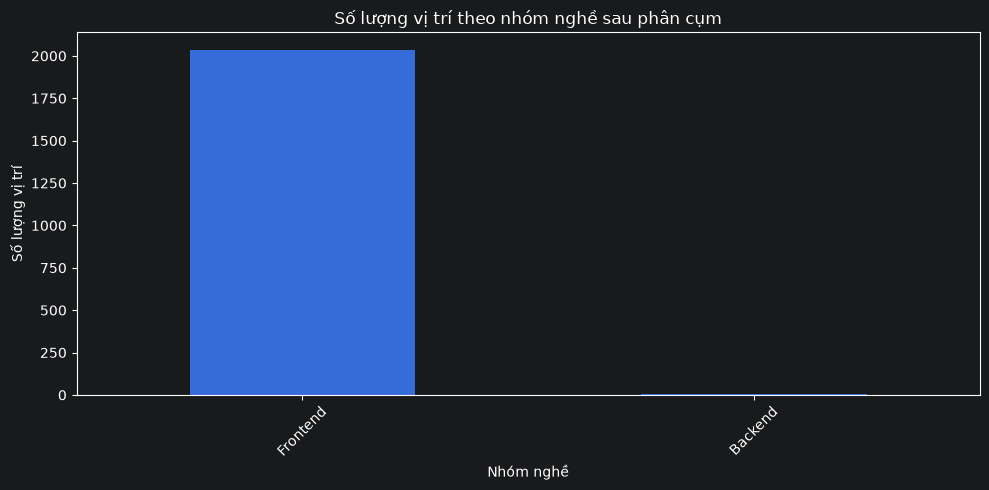

In [28]:
print("\n" + "=" * 70)
print("KẾT QUẢ PHÂN CỤM VỊ TRÍ TUYỂN DỤNG CNTT")
print("=" * 70)
#
career_cluster_count = (
    df["Ten_nhom_nghe"]
    .value_counts()
)

for nhom, so_luong in career_cluster_count.items():
    print(f"{nhom:<20}: {so_luong}")
#
nhom_lon_nhat = career_cluster_count.index[0]
so_luong_lon_nhat = career_cluster_count.iloc[0]

print("\n" + "-" * 70)

print(f"Nhóm nghề có số lượng lớn nhất: {nhom_lon_nhat}")
print(f"Số lượng vị trí: {so_luong_lon_nhat}")

print("-" * 70)

temp = df[
    df["Ten_nhom_nghe"] == nhom_lon_nhat
]

top_skills = (
    skill_matrix
    .loc[temp.index]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop kỹ năng phổ biến nhất của nhóm này:")

for skill, count in top_skills.items():
    print(f"{skill:<30} {int(count)}")

# Biểu đồ
plt.figure(figsize=(10,5))

career_cluster_count.plot(
    kind="bar"
)

plt.title(
    "Số lượng vị trí theo nhóm nghề sau phân cụm"
)

plt.xlabel("Nhóm nghề")
plt.ylabel("Số lượng vị trí")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()